```{math}
\def\b{\mathsf{b}}
\def\c{\mathsf{c}}
\def\kappab{\kappa_{\b}}
\def\kappac{\kappa_{\c}}
\def\kappabstar{k_{\b}}
\def\kappacstar{k_{\c}}
```

% Does this get parsed?
% def\kappabstar{\hat{\kappa}_{\b}}
% \def\kappacstar{\hat{\kappa}_{\c}}

(equilibrium)=
# Equilibrium formalism  

To illustrate the equilibrium formalism for receptor models, we will repeat our analysis of sequential binding using a standard notation. We begin with the weighted rooted spanning tree that specifies the equilibrium receptor model.

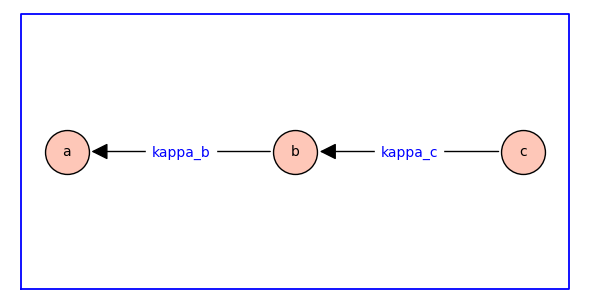

In [1]:
var('a b c kappa_b kappa_c')
T = DiGraph([[a,b,c],[(b,a),(c,b)]])
T.set_edge_label(b,a,kappa_b)
T.set_edge_label(c,b,kappa_c)
T.plot(figsize=6,pos={a:(0,0),b:(2,0),c:(4,0)},edge_labels=True,graph_border=True,vertex_size=1000)

In the diagram above, {math}`\kappab` and {math}`\kappac` are dimensionless equilibrium constants.  

The edges of the spanning tree are directed backwards, i.e., the forward reaction is against the direction of the arrow.  For example, the reaction labelled with the equilibrium constant {math}`\kappab` has {math}`a` as reactant and {math}`b` as product; consequently, increasing {math}`\kappab` decreases the equilibrium probability (relative fraction) of state {math}`a` and increases the probability of state {math}`b`.

The three states are labelled so that the reactant comes before the product in dictionary order ({math}`a` to {math}`b` to {math}`c`).  The subscript of the equilibrium constants {math}`\kappab` and {math}`\kappac` are chosen to match the label of the _products_.

The dependence on ligand concentration is encorporated by defining {math}`\kappab = \kappabstar x` and {math}`\kappac = \kappacstar x` where {math}`\kappabstar` and {math}`\kappacstar` are association constants with physical dimension of inverse concentration, and {math}`x` is ligand concentration.

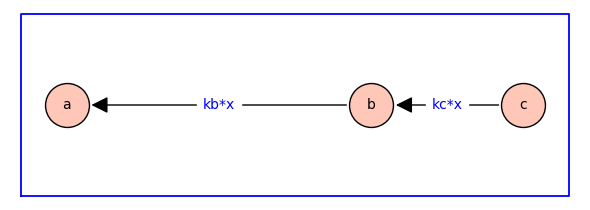

In [2]:
var('a b c x kb kc')
T = DiGraph([[a,b,c],[(b,a),(c,b)]])
T.set_edge_label(b,a,kb*x)
T.set_edge_label(c,b,kc*x)
T.plot(figsize=6,pos={a:(0,0),b:(4,0),c:(6,0)},edge_labels=True,graph_border=True,vertex_size=1000)

## Probability of each state 

For the equilibrium receptor model above, the probability of state {math}`i` is given by
{math}`\pi_i = z_i / z_T` where  {math}`z_T= \textstyle \sum_i z_i`,
{math}`z_a = 1`,
{math}`z_b = \kappab = \kappabstar x`, and
{math}`z_c =\kappab \kappac = \kappabstar \kappacstar x^2`. That is,

\begin{equation}
\pi_a =  \frac{1}{1+ \kappabstar x  +  \kappabstar \kappacstar x^2} \, ,  \quad \pi_b =  \frac{\kappabstar x}{1+ \kappabstar x +  \kappabstar  \kappacstar x^2}   \quad \mbox{and}  \quad \pi_c = \frac{\kappabstar  \kappacstar x^2 }{1+ \kappabstar x +  \kappabstar \kappacstar x^2 }  \, .
\end{equation}

It is helpful to  present this set of rational functions using the following compact notation:
\begin{equation}
 [ \pi_a  :  \pi_b :  \pi_c ] = [1 :\kappab : \kappab \kappac ]  = [1 : \kappabstar x :\kappabstar \kappacstar x^2  ] \,  .
\end{equation}

In expressions of this kind,  it is understood that
\begin{equation}
[ z_1 \! : \! z_2 : \! \cdots \! : \! z_n ] = [ \lambda z_1 \! : \! \lambda  z_2 : \! \cdots \! : \! \lambda  z_n ]
\end{equation}
for any {math}`\lambda \neq 0`.  Furthermore, {math}`\lambda = 1/\sum_i x_n` gives the probability distribution {math}`\pi = (\pi_1, \pi_2, \ldots, \pi_n)` where {math}`1=\sum_i \pi_i`.  Prior to normalization, we will refer to {math}`[ z_1 \! : \! z_2 : \! \cdots \! : \! z_n ]` as _relative probabilites_ for each receptor state.


## From spanning tree to relative probabilities

By using a spanning tree as the specification for the receptor model, it is straightforward to extract symbolic expressions for the fraction of receptors in each state.

In [3]:
paths = T.all_simple_paths(starting_vertices=[a,b,c],ending_vertices=[a],trivial=True)
print(paths)

[[a], [b, a], [c, b, a]]


The list `paths` has length 3. `paths[0]=[a]`.  `paths[1]=[b,a]`.  `paths[2]=[c,b,a]`.  These are vertices encountered in paths beginning at vertex 0 (`a`), 1 (`b`), and 2 (`c`) and (in each case) ending at vertex `a`.

The relative probability of each state is obtained as the product of the edge weights in each path, with the trivial path yielding 1 (an empty product).

In [4]:
z = []
for p in paths:
    w = 1
    for i in range(len(p)-1):
       w = w*T.edge_label(p[i],p[i+1])
    z.append(w)
print(z)

[1, kb*x, kb*kc*x^2]


The list `z` also has length 3.  `z[0]` is 1.  `z[1]=kb*x`.  `z[2]=kb*kc*x^2`.  These are the relative probabilities `z_a`, `z_b`, and `z_c`.

Symbolic expressions for the normalized probabilities are found as follows.

In [5]:
ztot = sum(z);
prob = []
for i in range(len(z)):
    prob.append(z[i]/ztot)
print(prob)

[1/(kb*kc*x^2 + kb*x + 1), kb*x/(kb*kc*x^2 + kb*x + 1), kb*kc*x^2/(kb*kc*x^2 + kb*x + 1)]


## References

```{bibliography}
:filter: docname in docnames
```